# Unemployment Analysis with Python

### Analyzing Unemployment Trends, Regional Differences, Labour Participation and COVID-19 Impact in India

## 2. Problem Statement

Unemployment is an important economic indicator that reflects the condition of the labour market.

The objective of this project is to analyze unemployment data from different regions of India and identify:

- Regional differences in unemployment rates
- Monthly unemployment trends
- Changes in unemployment during the COVID-19 period
- Relationship between unemployment, employment and labour participation
- Regions with relatively high average unemployment rates

The analysis will use Python-based data analysis and visualization techniques to identify meaningful patterns and trends in the dataset.

## 3. Objectives

The main objectives of this project are:

1. Load and understand the unemployment dataset.
2. Clean and prepare the data for analysis.
3. Analyze average unemployment rates across regions.
4. Study month-wise unemployment trends.
5. Visualize unemployment trends for major regions.
6. Identify the top 10 regions with the highest average unemployment rate.
7. Analyze correlations between unemployment rate, employment and labour participation.
8. Visualize correlations using a heatmap.
9. Compare unemployment before and during the COVID-19 period.
10. Extract meaningful insights from the analysis.

## 4. What Are We Building?

We are building an exploratory data analysis system for unemployment data.

The analysis pipeline will follow:

Dataset
→ Data Cleaning
→ Statistical Analysis
→ Regional Analysis
→ Time-Series Analysis
→ Correlation Analysis
→ COVID-19 Comparison
→ Data Visualization
→ Insights

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import kagglehub
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download(
    "gokulrajkmv/unemployment-in-india"
)

print("Dataset path:")
print(path)

print("\nFiles available in the dataset:")
print(os.listdir(path))

100%|██████████| 16.0k/16.0k [00:00<00:00, 10.9MB/s]

Extracting files...
Dataset path:
/root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5

Files available in the dataset:
['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [3]:
import os
import pandas as pd

file1 = os.path.join(path, "Unemployment_Rate_upto_11_2020.csv")
file2 = os.path.join(path, "Unemployment in India.csv")

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("========== FILE 1 ==========")
print("File:", "Unemployment_Rate_upto_11_2020.csv")
print("Shape:", df1.shape)
print("Columns:", df1.columns.tolist())
display(df1.head())

print("\n========== FILE 2 ==========")
print("File:", "Unemployment in India.csv")
print("Shape:", df2.shape)
print("Columns:", df2.columns.tolist())
display(df2.head())

========== FILE 1 ==========
File: Unemployment_Rate_upto_11_2020.csv
Shape: (267, 9)
Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



========== FILE 2 ==========
File: Unemployment in India.csv
Shape: (768, 7)
Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


##  Dataset Collection and Loading

The dataset used for this analysis is the **Unemployment in India** dataset.

The dataset contains unemployment-related information across different regions of India, including unemployment rate, estimated employment, labour participation rate and area classification.

The dataset covers the period before and during the COVID-19 period, allowing us to study changes in unemployment over time.

In [4]:
final_file = os.path.join(
    path,
    "Unemployment in India.csv"
)

# Load the dataset
df = pd.read_csv(final_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
print("Dataset Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:
1. Region
2.  Date
3.  Frequency
4.  Estimated Unemployment Rate (%)
5.  Estimated Employed
6.  Estimated Labour Participation Rate (%)
7. Area


##  Dataset Understanding

Before performing any analysis, we inspect the structure, data types, missing values and duplicate records in the dataset.

This helps us understand the quality and structure of the data before applying any cleaning or transformation.

In [6]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
# Check data types of all columns

print("Data Types:")
print(df.dtypes)

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [8]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [9]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 27


In [10]:
# Display statistical summary of numerical columns

print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [11]:
# Check unique regions

print("Number of unique regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].unique())

Number of unique regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']


In [12]:
# Check Rural / Urban distribution

print("Area Distribution:")
print(df["Area"].value_counts())

Area Distribution:
Area
Urban    381
Rural    359
Name: count, dtype: int64


In [13]:
# Check frequency values

print("Frequency Distribution:")
print(df["Frequency"].value_counts())

Frequency Distribution:


KeyError: 'Frequency'

## Data Cleaning

The dataset contains leading spaces in some column names. These spaces can cause errors when accessing columns programmatically.

We will standardize the column names by removing leading and trailing whitespace.

In [14]:
# Clean column names

df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [15]:
# Inspect rows containing missing values

missing_rows = df[df.isnull().any(axis=1)]

print("Number of rows containing missing values:", len(missing_rows))

display(missing_rows)

Number of rows containing missing values: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Inspect duplicate rows

duplicates = df[df.duplicated(keep=False)]

print("Number of rows involved in duplicates:", len(duplicates))

display(duplicates.head(20))

Number of rows involved in duplicates: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Removing Completely Empty Rows

The dataset contains 28 rows where every column is missing.

Since these rows contain no usable information, they will be removed before further analysis.

In [17]:
# Remove completely empty rows

rows_before = len(df)

df = df.dropna(how="all").copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Rows before removing empty rows:", rows_before)
print("Empty rows removed:", rows_removed)
print("Rows after removing empty rows:", rows_after)

Rows before removing empty rows: 768
Empty rows removed: 28
Rows after removing empty rows: 740


In [18]:
# Check duplicate records after removing empty rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 0


### Verification After Data Cleaning

After removing the completely empty rows, we verify the dataset for remaining missing values, duplicate records and its final shape.

In [19]:

print("Cleaned Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Cleaned Dataset Shape: (740, 7)

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate Rows: 0

First 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Date Conversion

The `Date` column is currently stored as text. Since this project involves month-wise and time-series analysis, the date values need to be converted into Pandas datetime format.

In [20]:

print("Date column data type before conversion:")
print(df["Date"].dtype)

Date column data type before conversion:
object


In [23]:

test_dates = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

invalid_dates = df.loc[
    test_dates.isna(),
    "Date"
]

print("Number of invalid date values:", invalid_dates.shape[0])

print("\nInvalid date values:")
print(invalid_dates.unique())

Number of invalid date values: 740

Invalid date values:
[' 31-05-2019' ' 30-06-2019' ' 31-07-2019' ' 31-08-2019' ' 30-09-2019'
 ' 31-10-2019' ' 30-11-2019' ' 31-12-2019' ' 31-01-2020' ' 29-02-2020'
 ' 31-03-2020' ' 30-04-2020' ' 31-05-2020' ' 30-06-2020']


In [24]:
# Remove leading and trailing whitespace from Date values

df["Date"] = df["Date"].str.strip()

print("Whitespace removed from Date values.")

print("\nSample Date values:")
print(df["Date"].head())

Whitespace removed from Date values.

Sample Date values:
0    31-05-2019
1    30-06-2019
2    31-07-2019
3    31-08-2019
4    30-09-2019
Name: Date, dtype: object


In [25]:
# Convert Date column from text to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

print("Date column converted successfully!")
print("Date column data type:", df["Date"].dtype)

Date column converted successfully!
Date column data type: datetime64[ns]


In [26]:
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

print("\nNumber of unique dates:", df["Date"].nunique())

print("\nSample converted dates:")
print(df["Date"].head())

Earliest Date: 2019-05-31 00:00:00
Latest Date: 2020-06-30 00:00:00

Number of unique dates: 14

Sample converted dates:
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [27]:

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%B")

print("Year and Month columns created successfully!")

display(
    df[["Date", "Year", "Month", "Month_Name"]].head()
)

Year and Month columns created successfully!


,Date,Year,Month,Month_Name
0,2019-05-31,2019,5,May
1,2019-06-30,2019,6,June
2,2019-07-31,2019,7,July
3,2019-08-31,2019,8,August
4,2019-09-30,2019,9,September


In [28]:
# Basic statistical summary

print("Basic Statistical Summary:")
display(df.describe())

Basic Statistical Summary:


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year,Month
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,2019.418919,6.390541
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000,1.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000,4.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000,6.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000,9.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000,12.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716,3.235070


In [29]:
region_avg_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:")
display(region_avg_unemployment)

Average Unemployment Rate by Region:


,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [30]:
# Calculate month-wise average unemployment rate

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_index()
)

print("Month-wise Average Unemployment Rate:")
display(monthly_unemployment)

Month-wise Average Unemployment Rate:


,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731
2019-10-31,9.900909
2019-11-30,9.868364
2019-12-31,9.497358
2020-01-31,9.950755


## Time-Series Analysis

### Objective

Analyze how the unemployment rate changed over time across selected regions.

### What We Are Doing

- Select three regions for comparison.
- Calculate the unemployment rate for each region over time.
- Visualize the trends using a line chart.
- Compare the changes across the selected regions.

### Selected Regions

- Tamil Nadu
- Maharashtra
- Haryana



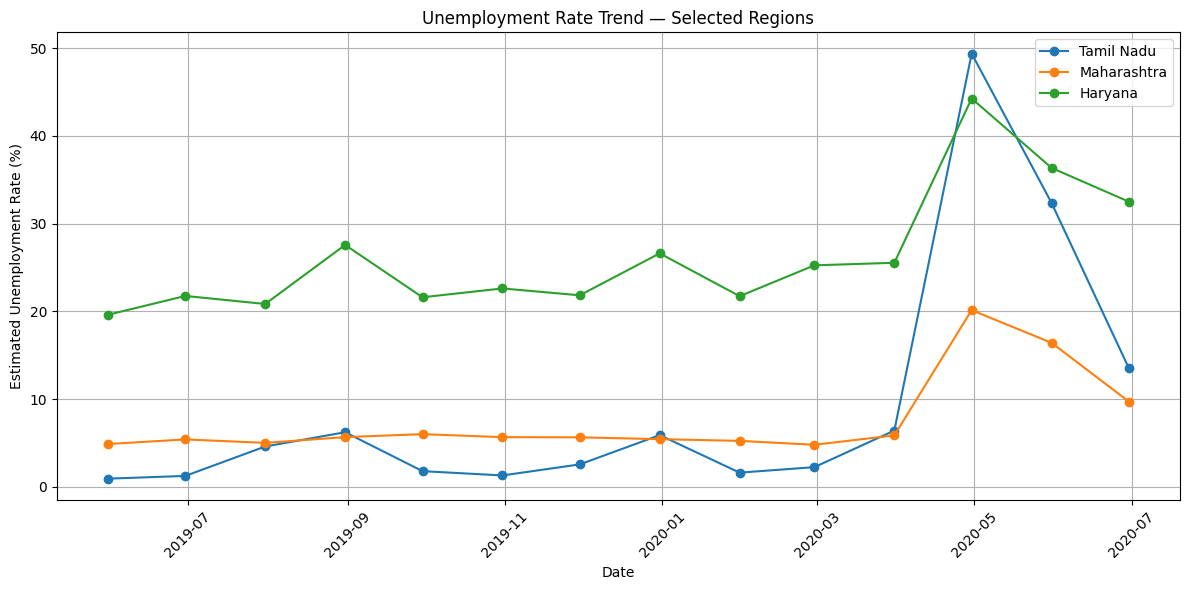

In [31]:

import matplotlib.pyplot as plt

# Select three regions for time-series analysis
selected_regions = [
    "Tamil Nadu",
    "Maharashtra",
    "Haryana"
]

# Create the plot
plt.figure(figsize=(12, 6))

for region in selected_regions:

    region_data = (
        df[df["Region"] == region]
        .groupby("Date")["Estimated Unemployment Rate (%)"]
        .mean()
        .sort_index()
    )

    plt.plot(
        region_data.index,
        region_data.values,
        marker="o",
        label=region
    )

# Chart formatting
plt.title("Unemployment Rate Trend — Selected Regions")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Display chart
plt.show()

## Top 10 Regions by Average Unemployment

### Objective

Identify the 10 regions with the highest average unemployment rate during the study period.

### What We Are Doing

- Use the region-wise average unemployment calculated earlier.
- Select the top 10 regions.
- Visualize them using a horizontal bar chart.
- Compare unemployment levels across the highest-affected regions.



Top 10 Regions by Average Unemployment Rate:


,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


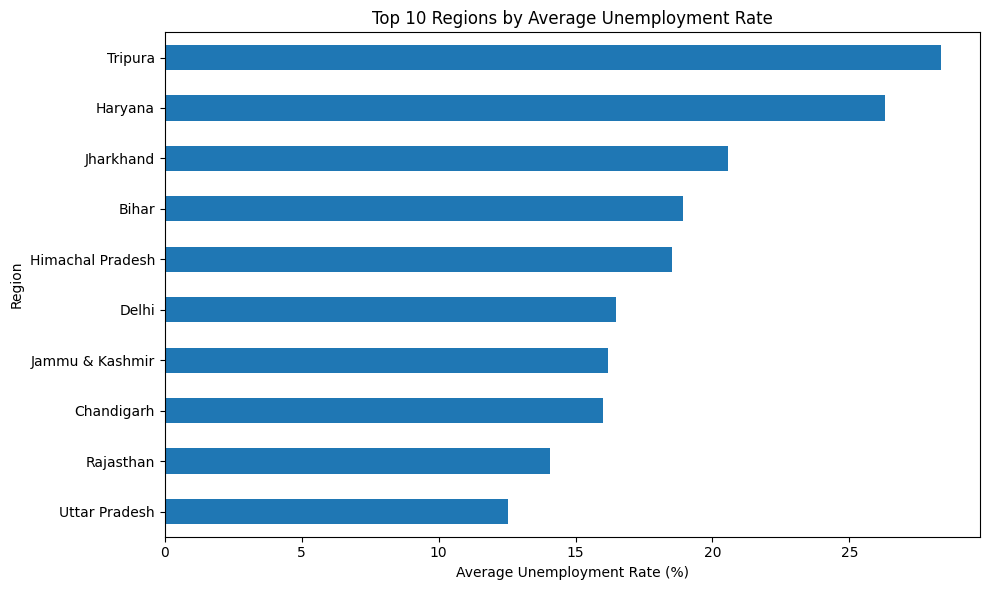

In [32]:

top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Regions by Average Unemployment Rate:")
display(top_10_regions)

# Plot
plt.figure(figsize=(10, 6))

top_10_regions.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()

plt.show()

## Correlation Analysis

### Objective

Analyze the relationships between unemployment rate, employment, and labour participation rate.

### What We Are Doing

- Select the three required numerical variables.
- Calculate their pairwise correlations.
- Understand whether the variables move together positively or negatively.
- Use the results as the basis for the correlation heatmap.



In [33]:

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


## Correlation Heatmap

### Objective

Visualize the correlation between unemployment rate, estimated employment, and labour participation rate.

### What We Are Doing

- Use the correlation matrix calculated in Step 18.
- Represent the correlation values using a heatmap.
- Display the numerical correlation values inside each cell.
- Use the visualization to identify positive, negative, and weak relationships.



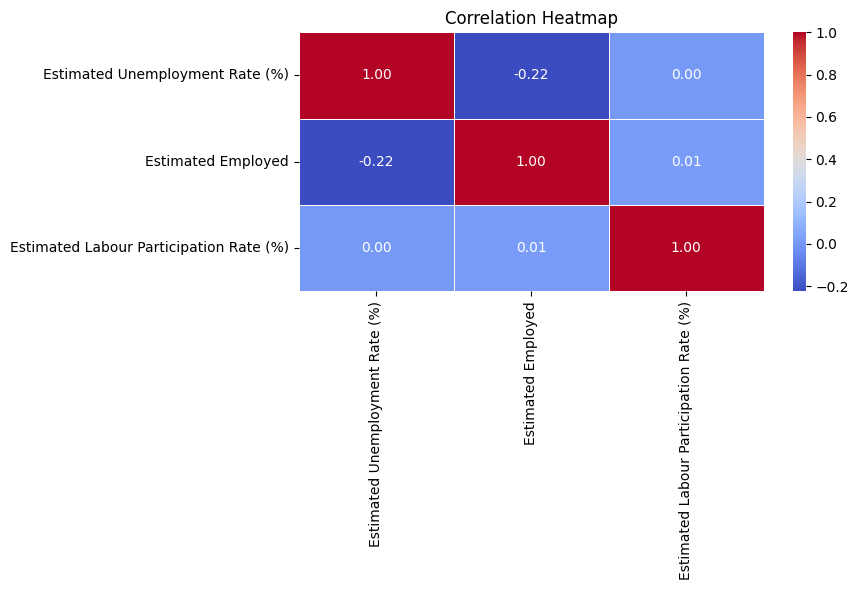

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

## Pre-COVID vs COVID Analysis

### Objective

Compare unemployment levels before and during the COVID-19 period.

### Period Definition

- **Pre-COVID:** May 2019 to February 2020
- **COVID Period:** March 2020 to June 2020

### What We Are Doing

- Divide the dataset into two time periods.
- Calculate the average unemployment rate for each period.
- Compare the average unemployment levels.
- Use the results for the COVID impact visualization.



In [35]:
pre_covid = df[
    df["Date"] < "2020-03-01"
].copy()

covid_period = df[
    df["Date"] >= "2020-03-01"
].copy()

# Calculate average unemployment rate
pre_covid_avg = pre_covid[
    "Estimated Unemployment Rate (%)"
].mean()

covid_avg = covid_period[
    "Estimated Unemployment Rate (%)"
].mean()

print("Pre-COVID Period:")
print("May 2019 to February 2020")
print("Average Unemployment Rate:", round(pre_covid_avg, 2), "%")

print("\nCOVID Period:")
print("March 2020 to June 2020")
print("Average Unemployment Rate:", round(covid_avg, 2), "%")

Pre-COVID Period:
May 2019 to February 2020
Average Unemployment Rate: 9.51 %

COVID Period:
March 2020 to June 2020
Average Unemployment Rate: 17.77 %


##  COVID Impact Visualization

### Objective

Visualize the difference in average unemployment rate between the pre-COVID and COVID periods.

### What We Are Doing

- Use the average unemployment rates calculated in Step 20.
- Create a comparison bar chart.
- Display the unemployment rate for both periods.
- Make the change easier to interpret visually.



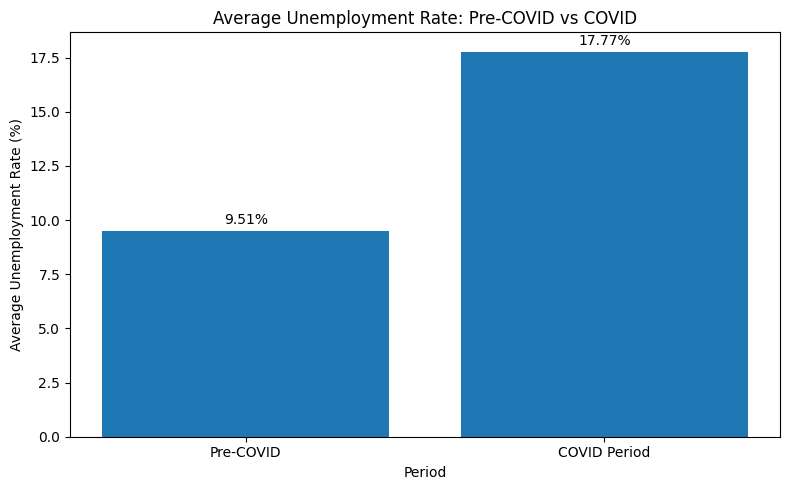

In [36]:

import matplotlib.pyplot as plt

periods = [
    "Pre-COVID",
    "COVID Period"
]

average_rates = [
    pre_covid_avg,
    covid_avg
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    periods,
    average_rates
)

plt.title("Average Unemployment Rate: Pre-COVID vs COVID")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

# Display values above bars
for bar, value in zip(bars, average_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Key Findings

### 1. Overall Unemployment

The average unemployment rate across the cleaned dataset was approximately **11.79%**.

### 2. Regional Variation

The average unemployment rate varied substantially across regions.

The highest regional averages in this dataset were observed in:

- Tripura — 28.35%
- Haryana — 26.28%
- Jharkhand — 20.59%
- Bihar — 18.92%
- Himachal Pradesh — 18.54%

### 3. Monthly Trend

The overall monthly unemployment rate remained around **9–10%** for much of the period from May 2019 to March 2020.

The rate increased substantially in April and May 2020, reaching:

- April 2020 — 23.64%
- May 2020 — 24.88%

It then decreased to **11.90% in June 2020**.

### 4. Pre-COVID vs COVID Comparison

The average unemployment rate was:

- Pre-COVID period — **9.51%**
- COVID period — **17.77%**

This represents a difference of approximately **8.26 percentage points** between the two defined periods.

### 5. Correlation Analysis

The correlation between unemployment rate and estimated employment was approximately **-0.22**.

The correlation between unemployment rate and labour participation rate was approximately **0.00**, while the correlation between estimated employment and labour participation rate was approximately **0.01**.

### 6. Data Quality

After cleaning:

- Original records — 768
- Valid records — 740
- Empty rows removed — 28
- Duplicate rows remaining — 0
- Missing values remaining — 0



##   Conclusion

### Project Summary

This project analyzed unemployment trends in India using regional and monthly unemployment data.

The analysis covered data cleaning, statistical analysis, regional comparison, monthly trends, time-series visualization, correlation analysis, and a comparison of unemployment levels before and during the defined COVID period.

### Key Outcomes

- Cleaned and analyzed **740 valid records**.
- Calculated average unemployment rates for different regions.
- Identified the **Top 10 regions** with the highest average unemployment rates.
- Analyzed monthly unemployment trends from **May 2019 to June 2020**.
- Compared unemployment trends across **Tamil Nadu, Maharashtra, and Haryana**.
- Examined relationships between unemployment, estimated employment, and labour participation.
- Compared the average unemployment rate between the pre-COVID and COVID periods.
- Created visualizations including line charts, bar charts, and a correlation heatmap.

### Final Observation

The dataset shows substantial regional and time-based variation in unemployment rates. The average unemployment rate was **9.51% during the defined pre-COVID period** and **17.77% during the defined COVID period**.

This analysis provides a descriptive view of unemployment patterns in the dataset and demonstrates how Python-based data analysis and visualization can be used to investigate economic trends.



## Future Improvements

This project can be extended in several ways to make the analysis more detailed and robust.

### 1. Use More Recent Data

Extend the analysis with newer unemployment datasets to study trends beyond June 2020.

### 2. More Detailed Time-Series Analysis

Apply advanced time-series techniques to study seasonality, long-term trends, and changes in unemployment over time.

### 3. Regional-Level Analysis

Perform deeper analysis for individual states and regions to understand differences in unemployment patterns.

### 4. Statistical Analysis

Use statistical tests to investigate whether observed differences between periods are statistically significant.

### 5. Interactive Dashboard

Build an interactive dashboard using tools such as Plotly, Streamlit, or Power BI to allow users to explore regions and time periods dynamically.

### 6. Predictive Modeling

Develop machine learning models to predict future unemployment rates using historical unemployment, employment, and labour participation data.

### 7. Additional Economic Indicators

Combine unemployment data with other economic indicators such as GDP growth, inflation, and sector-wise employment for broader analysis.



#  Final Architecture

## End-to-End Project Workflow

The complete unemployment analysis follows this workflow:

```text
Kaggle Dataset
      ↓
Dataset Download
      ↓
Inspect Dataset Files
      ↓
Select Unemployment in India Dataset
      ↓
Data Loading
      ↓
Data Cleaning
      ├── Clean Column Names
      ├── Remove Empty Rows
      ├── Check Duplicates
      └── Verify Missing Values
      ↓
Date Processing
      ├── Remove Date Whitespace
      ├── Convert Date to Datetime
      ├── Extract Year
      ├── Extract Month
      └── Extract Month Name
      ↓
Exploratory Data Analysis
      ├── Basic Statistics
      ├── Region-wise Average Unemployment
      └── Month-wise Unemployment Trend
      ↓
Time-Series Analysis
      └── Compare Selected Regions
          ├── Tamil Nadu
          ├── Maharashtra
          └── Haryana
      ↓
Regional Analysis
      └── Top 10 Regions by Average Unemployment
      ↓
Correlation Analysis
      ├── Unemployment Rate
      ├── Estimated Employed
      └── Labour Participation Rate
      ↓
Correlation Heatmap
      ↓
COVID Period Analysis
      ├── Pre-COVID Period
      ├── COVID Period
      └── Average Unemployment Comparison
      ↓
Visualizations
      ├── Line Chart
      ├── Bar Chart
      └── Heatmap
      ↓
Key Findings
      ↓
Conclusion
      ↓
Future Improvements